# Proyecto Final de Módulo
## Clasificador de texto para agente geoespacial multiagente

**Curso:** Machine Learning (Aprendizaje de Máquina) 

**Descripción:** Sistema de clasificación de texto que detecta la intención del usuario en lenguaje natural y la redirige al agente geoespacial correspondiente dentro de una arquitectura multiagente.

**Nombre**: Oldrin Santiago Bonilla Cáceres - Maestrante de Ciencia de Datos

---

## 0. Setup de notebook

In [52]:
import os           # manejo de variables de entorno y rutas del sistema
import json         # lectura y escritura de archivos JSON / JSONL
import re           # expresiones regulares para limpieza de texto
import warnings     # suprimir advertencias no críticas durante ejecución
import logging      # registro de eventos y mensajes del pipeline
from pathlib import Path          # rutas de archivos multiplataforma (Windows/Linux)
from collections import Counter   # conteo de frecuencias de elementos

import numpy as np          # operaciones numéricas y manejo de arrays
import pandas as pd         # manipulación y análisis de datos tabulares
import matplotlib.pyplot as plt  # visualizaciones y gráficas estáticas
import seaborn as sns       # visualizaciones estadísticas de alto nivel
import joblib               # serialización y carga de modelos entrenados (.pkl)
from scipy import stats     # test estadísticos (Wilcoxon, t-test)

from sklearn.pipeline import Pipeline, FeatureUnion   # encadenamiento de pasos ML y combinación de features
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer  # vectorización de texto (TF-IDF y BoW)
from sklearn.feature_selection import SelectKBest, chi2  # selección de features por chi-cuadrado
from sklearn.svm import LinearSVC                        # clasificador SVM lineal (baseline)
from sklearn.naive_bayes import MultinomialNB            # clasificador Naive Bayes para texto
from sklearn.neural_network import MLPClassifier         # red neuronal densa (modelo avanzado)
from sklearn.calibration import CalibratedClassifierCV   # calibración de probabilidades para SVM
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler  # codificación de labels y normalización
from sklearn.model_selection import (
    train_test_split,          # división train/test estratificada
    RepeatedStratifiedKFold,   # validación cruzada repetida con estratificación
    GridSearchCV,              # búsqueda exhaustiva de hiperparámetros
    cross_val_score,           # evaluación con validación cruzada
    learning_curve             # curvas de aprendizaje train vs validación
)
from sklearn.metrics import (
    classification_report,     # reporte completo precision/recall/F1 por clase
    confusion_matrix,          # matriz de confusión
    ConfusionMatrixDisplay,    # visualización de matriz de confusión
    f1_score                   # métrica F1 para evaluación multiclase
)
from sklearn.manifold import TSNE  # reducción de dimensionalidad para visualización 2D

import optuna  # optimización bayesiana de hiperparámetros (extra)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Paths
ROOT          = Path('..') 
RAW_DATA      = ROOT / 'data/raw/intents_raw.jsonl'
CLEAN_DATA    = ROOT / 'data/interim/intents_clean.jsonl'
MODEL01_PATH  = ROOT / 'models/model01.pkl'
MODEL02_PATH  = ROOT / 'models/model02.pkl'
LE_PATH       = ROOT / 'models/label_encoder.pkl'

RANDOM_STATE = 42
TEST_SIZE    = 0.2
CV_N_SPLITS  = 10
CV_N_REPEATS = 10

INTENT_LABELS = [
    'query_layer', 'spatial_filter', 'calculate_area', 'get_attributes',
    'export_data', 'visualize_map', 'spatial_join', 'buffer_analysis'
]

print('Setup completado')
print(f'  model01 existe: {MODEL01_PATH.exists()}')
print(f'  model02 existe: {MODEL02_PATH.exists()}')
print(f'  corpus raw    : {RAW_DATA.exists()}')
print(f'  corpus clean  : {CLEAN_DATA.exists()}')

Setup completado
  model01 existe: True
  model02 existe: True
  corpus raw    : True
  corpus clean  : True


## 1. Introducción

### Problema
En arquitecturas multiagente modernas, el sistema debe interpretar instrucciones en lenguaje natural y redirigirlas al agente especializado correspondiente. Sin un clasificador de intención, el sistema no sabe a qué agente enviar cada instrucción.

### Propuesta
Desarrollar un **clasificador de texto** que, dada una instrucción del usuario en español, identifique automáticamente la intención geoespacial y la dirija al **agente geoespacial** correspondiente.

### Importancia
- Los Sistemas de Información Geográfica (GIS) son herramientas complejas que requieren conocimiento técnico especializado
- Permitir interacción en lenguaje natural democratiza el acceso al análisis espacial
- Un clasificador de intención es el componente central de cualquier asistente GIS conversacional

### Arquitectura multiagente
```
Usuario (voz/texto)
        ↓
Clasificador de Intención  ← este proyecto
        ↓
   Agente Geoespacial
   (GIS / análisis espacial)
```

### Clases de intención implementadas
| Intent | Descripción | Ejemplo |
|--------|-------------|---------|
| `query_layer` | Consultar capas disponibles | "muéstrame las capas del mapa" |
| `spatial_filter` | Filtrar por geometría | "filtra los polígonos del área" |
| `calculate_area` | Calcular áreas y medidas | "calcula el área de los parques" |
| `get_attributes` | Consultar atributos | "qué campos tiene la capa de ríos" |
| `export_data` | Exportar datos | "exporta los resultados a shapefile" |
| `visualize_map` | Cambiar simbología | "muestra el mapa por categoría" |
| `spatial_join` | Unir capas espacialmente | "cruza las capas por intersección" |
| `buffer_analysis` | Crear zonas de influencia | "crea un buffer de 500m" |

### Enfoque técnico
- **Corpus:** ~640 utterances en español generados con GROQ API (LLaMA 3.3 70B)
- **Model01 (baseline):** TF-IDF + chi² + LinearSVC / Naive Bayes  
- **Model02 (avanzado):** TF-IDF word+char n-grams + chi² + MLP
- **Tuning:** GridSearchCV + RepeatedStratifiedKFold (10×10) + Optuna (bayesiano)

## 2. Exploratory Data Analysis (EDA)

El corpus fue generado usando dos LLMs para mayor diversidad léxica:
- **GROQ API** (LLaMA 3.3 70B): 100 utterances por intent — frases variadas, cortas y largas
- **Mistral local** (Ollama): 50 utterances por intent — frases adicionales con distinto estilo

El código de generación está en `src/data/generator.py`.

Total generado: **~1146 ejemplos**.

In [53]:
# Cargar corpus crudo
corpus_raw = []
with open(RAW_DATA, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            corpus_raw.append(json.loads(line))

df = pd.DataFrame(corpus_raw)
print('=' * 50)
print('RESUMEN DEL DATASET')
print('=' * 50)
print(f'Total ejemplos  : {len(df)}')
print(f'Intents únicos  : {df["intent"].nunique()}')
print(f'Duplicados      : {df.duplicated(subset=["text"]).sum()}')
print(f'Textos nulos    : {df["text"].isnull().sum()}')
print()
df.head(8)

RESUMEN DEL DATASET
Total ejemplos  : 1146
Intents únicos  : 8
Duplicados      : 1
Textos nulos    : 0



,text,intent
0,Mostrar capas geoespaciales disponibles,query_layer
1,Ver capas en el mapa,query_layer
2,Quiero listar capas de uso de suelo,query_layer
3,Visualizar todas las capas disponibles,query_layer
4,Capas geoespaciales de esta zona,query_layer
5,Quiero ver las capas de mi proyecto,query_layer
6,Mostrar capas de infraestructura,query_layer
7,Listar capas de transporte en el área,query_layer


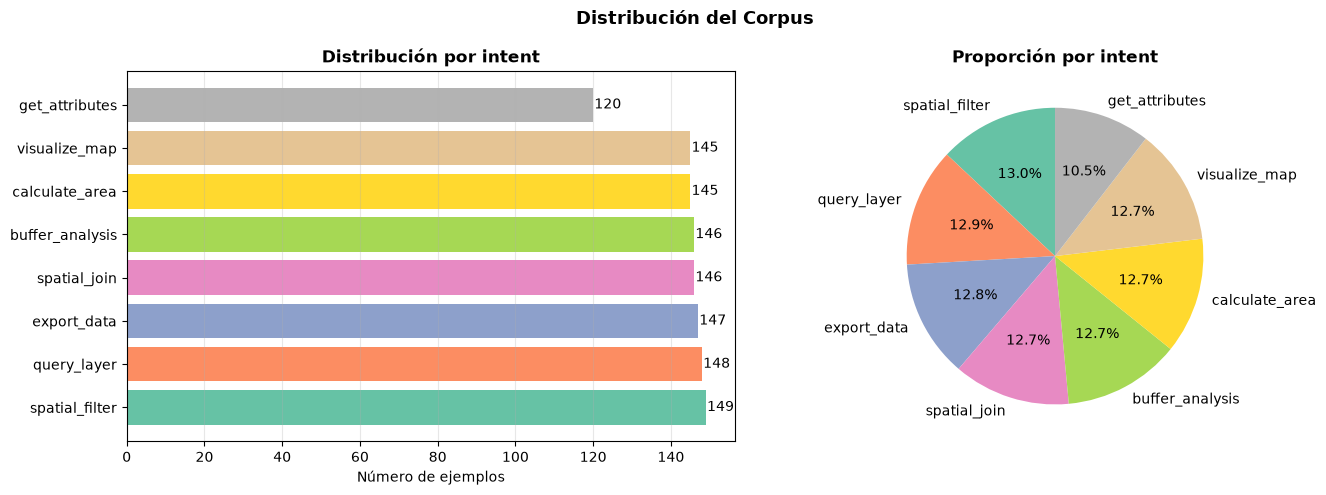

In [54]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['intent'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))

axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Número de ejemplos')
axes[0].set_title('Distribución por intent', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(counts.values):
    axes[0].text(v + 0.3, i, str(v), va='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Proporción por intent', fontweight='bold')

plt.suptitle('Distribución del Corpus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Se aprecia que el dataset esta balanceado

Estadísticas de longitud (palabras):
                 count  mean   std  min  25%  50%   75%   max
intent                                                       
buffer_analysis  146.0  9.45  4.24  3.0  6.0  8.0  14.0  17.0
calculate_area   145.0  8.30  3.84  3.0  6.0  7.0  12.0  16.0
export_data      147.0  8.01  5.38  2.0  4.0  6.0  10.0  21.0
get_attributes   120.0  9.66  3.81  4.0  7.0  9.0  14.0  16.0
query_layer      148.0  7.97  3.91  2.0  5.0  7.0  12.0  17.0
spatial_filter   149.0  8.32  4.12  3.0  5.0  7.0  12.0  17.0
spatial_join     146.0  8.56  4.53  2.0  5.0  7.0  12.0  19.0
visualize_map    145.0  7.76  4.17  2.0  4.0  8.0  12.0  16.0


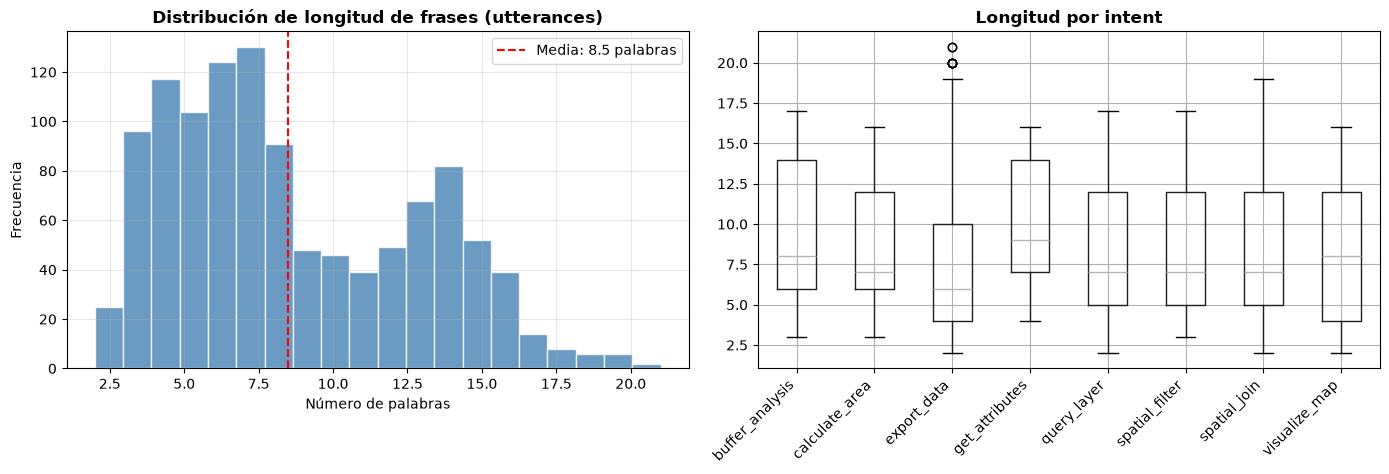

In [55]:
# Análisis de longitud
df['n_words'] = df['text'].str.split().str.len()
df['n_chars']  = df['text'].str.len()

print('Estadísticas de longitud (palabras):')
print(df.groupby('intent')['n_words'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['n_words'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df['n_words'].mean(), color='red', linestyle='--',
                label=f'Media: {df["n_words"].mean():.1f} palabras')
axes[0].set_xlabel('Número de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitud de frases (utterances)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

df.boxplot(column='n_words', by='intent', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_title('Longitud por intent', fontweight='bold')
axes[1].set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

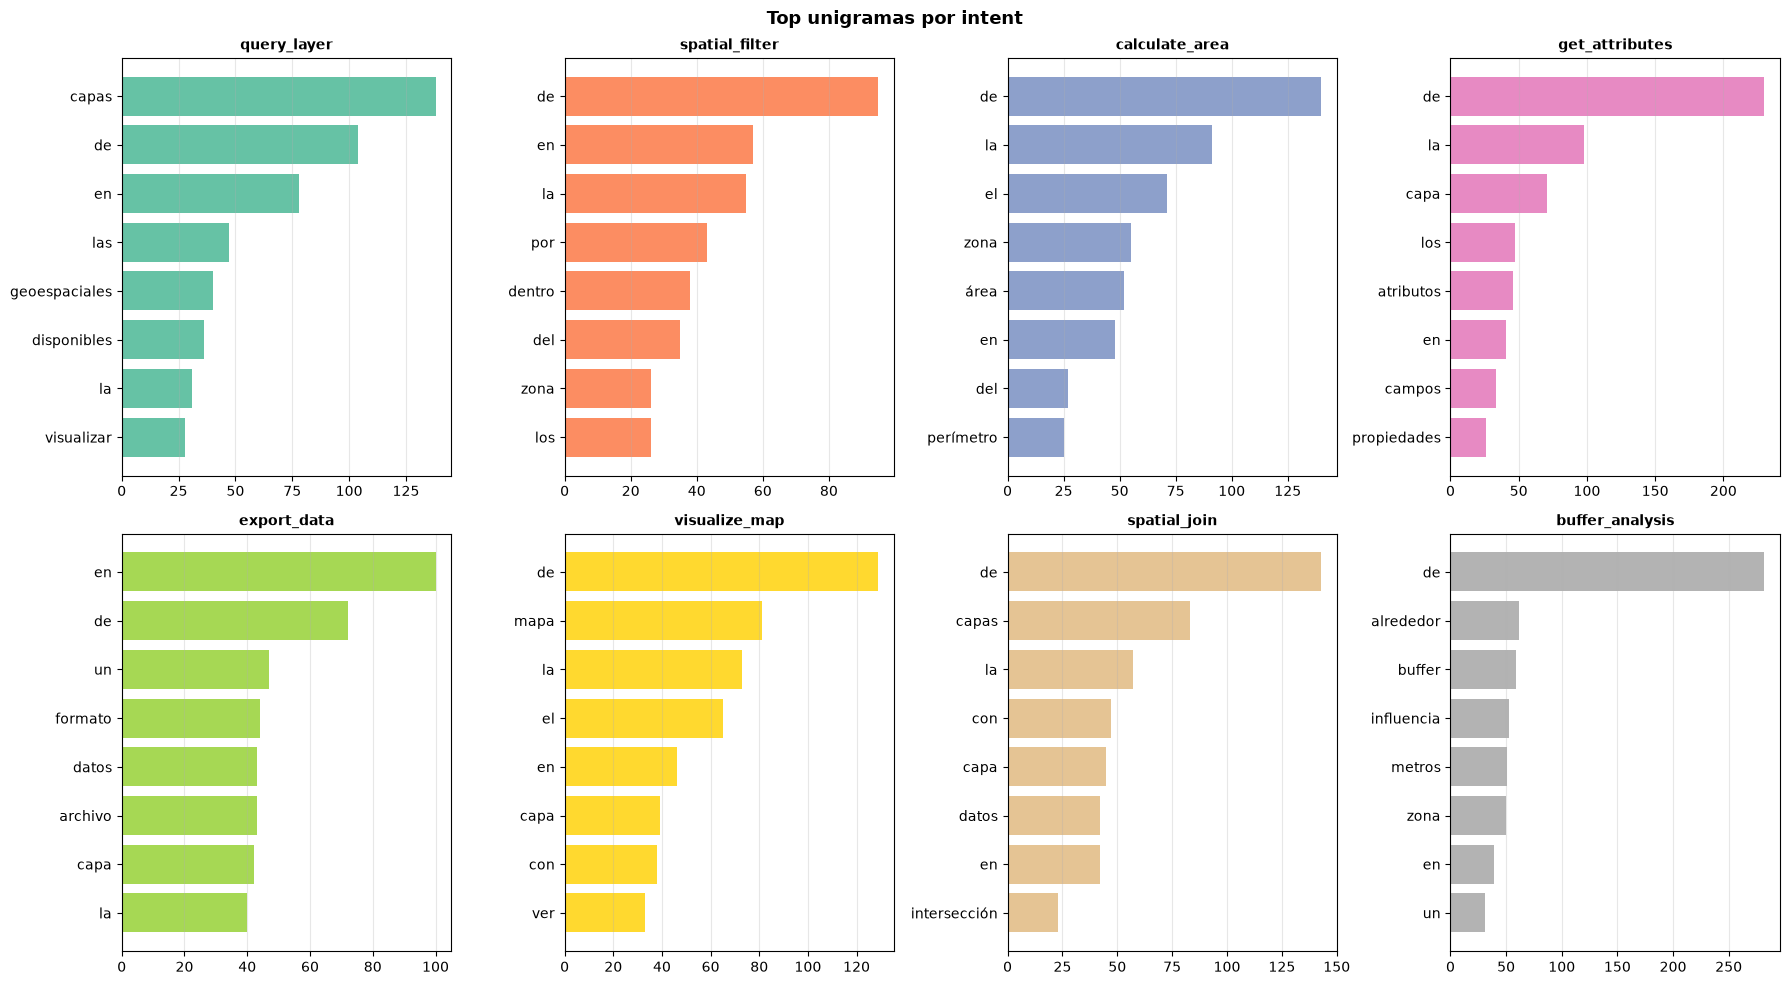

In [56]:
# Top n-grams por intent
def top_ngrams(texts, n=1, top_k=8):
    vec   = CountVectorizer(ngram_range=(n, n), max_features=top_k*5)  # cuenta ocurrencias de n-grams
    X     = vec.fit_transform(texts)                                     # matriz textos × términos
    freqs = np.asarray(X.sum(axis=0)).flatten()                         # frecuencia total de cada término
    terms = vec.get_feature_names_out()                                  # nombres de los términos
    top_i = freqs.argsort()[-top_k:][::-1]                              # índices de los top_k más frecuentes
    return [(terms[i], freqs[i]) for i in top_i]                        # devuelve (término, frecuencia)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))  # grilla 2×4, una por intent
axes = axes.flatten()                               # convierte matriz de ejes en lista plana

for idx, intent in enumerate(INTENT_LABELS):
    texts  = df[df['intent'] == intent]['text'].tolist()  # textos solo de este intent
    ngrams = top_ngrams(texts, n=1, top_k=8)              # top 8 unigramas del intent
    terms, freqs = zip(*ngrams)                            # separa términos y frecuencias
    axes[idx].barh(terms[::-1], freqs[::-1], color=plt.cm.Set2(idx/8))  # barras horizontales
    axes[idx].set_title(intent, fontweight='bold', fontsize=10)          # título = nombre del intent
    axes[idx].grid(axis='x', alpha=0.3)                                  # grilla suave en eje x

plt.suptitle('Top unigramas por intent', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Cada intent tiene un vocabulario claramente diferenciado dependiendo del objetivo del análisis geoespacial

## 3. Preprocesamiento de texto

Pipeline de limpieza implementado en `src/data/preprocess.py`:
1. Minúsculas
2. Eliminar caracteres especiales
3. Lematización con spaCy (`es_core_news_sm`)
4. Eliminación de stopwords

In [57]:
# Cargar corpus limpio
clean_records = []
with open(CLEAN_DATA, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            clean_records.append(json.loads(line))

df_clean = pd.DataFrame(clean_records)
print(f'Corpus limpio: {len(df_clean)} registros')
print(f'Corpus crudo : {len(df)} registros')
print(f'Descartados  : {len(df) - len(df_clean)} (textos muy cortos tras limpieza)')
print()

# Mostrar ejemplos de limpieza
print('Ejemplos de preprocesamiento:')
print('=' * 65)
for i in range(5):
    raw   = df_clean.iloc[i]['text_raw']
    clean = df_clean.iloc[i]['text']
    tok   = df_clean.iloc[i]['tokens']
    intent= df_clean.iloc[i]['intent']
    print(f'Intent  : {intent}')
    print(f'  Crudo : {raw}')
    print(f'  Limpio: {clean}')
    print(f'  Tokens: {tok}')
    print()

Corpus limpio: 1133 registros
Corpus crudo : 1146 registros
Descartados  : 13 (textos muy cortos tras limpieza)

Ejemplos de preprocesamiento:
Intent  : query_layer
  Crudo : Mostrar capas geoespaciales disponibles
  Limpio: mostrar capa geoespacial disponible
  Tokens: ['mostrar', 'capa', 'geoespacial', 'disponible']

Intent  : query_layer
  Crudo : Ver capas en el mapa
  Limpio: capa mapa
  Tokens: ['capa', 'mapa']

Intent  : query_layer
  Crudo : Quiero listar capas de uso de suelo
  Limpio: querer listar capa suelo
  Tokens: ['querer', 'listar', 'capa', 'suelo']

Intent  : query_layer
  Crudo : Visualizar todas las capas disponibles
  Limpio: visualizar capa disponible
  Tokens: ['visualizar', 'capa', 'disponible']

Intent  : query_layer
  Crudo : Capas geoespaciales de esta zona
  Limpio: capa geoespacial zona
  Tokens: ['capa', 'geoespacial', 'zona']



## 4. Feature Extraction

Se comparan tres representaciones vectoriales:
- **Bag of Words (BoW):** presencia/frecuencia de palabras
- **TF-IDF:** pondera términos por importancia estadística  
- **TF-IDF + n-grams:** captura bigramas como "calcular área", "exportar shapefile"

In [58]:
# Preparar datos
le = LabelEncoder()
le.fit(INTENT_LABELS)

X = df_clean['text'].values
y = le.transform(df_clean['intent'].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {len(X_train)} ejemplos | Test: {len(X_test)} ejemplos')

# Comparar representaciones
configs = {
    'Bag of Words':     CountVectorizer(max_features=3000, ngram_range=(1,1)),
    'TF-IDF':           TfidfVectorizer(max_features=5000, sublinear_tf=True),
    'TF-IDF + n-grams': TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True),
}

results = []
for name, vec in configs.items():
    X_vec   = vec.fit_transform(X_train)
    density = X_vec.nnz / (X_vec.shape[0] * X_vec.shape[1]) * 100
    results.append({'Representación': name, 'Shape': str(X_vec.shape),
                    'Vocabulario': len(vec.vocabulary_), 'Densidad (%)': f'{density:.2f}'})

print()
print(pd.DataFrame(results).to_string(index=False))

Train: 906 ejemplos | Test: 227 ejemplos

  Representación       Shape  Vocabulario Densidad (%)
    Bag of Words  (906, 490)          490         0.93
          TF-IDF  (906, 490)          490         0.93
TF-IDF + n-grams (906, 1990)         1990         0.41


In [59]:
# Top términos TF-IDF + n-grams por intent
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2),
                        sublinear_tf=True, min_df=2, strip_accents='unicode')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)
feature_names = tfidf.get_feature_names_out()

print('Top 6 términos TF-IDF por intent:')
print('=' * 60)
for class_idx, class_name in enumerate(le.classes_):
    mask       = y_train == class_idx
    mean_tfidf = np.asarray(X_train_vec[mask].mean(axis=0)).flatten()
    top_idx    = mean_tfidf.argsort()[-6:][::-1]
    top_terms  = [feature_names[i] for i in top_idx]
    print(f'{class_name:<22}: {" | ".join(top_terms)}')

Top 6 términos TF-IDF por intent:
buffer_analysis       : buffer | influencia | zona influencia | zona | metro | crear
calculate_area        : area | zona | medida | perimetro | calcular | area zona
export_data           : exportar | archivo | formato | dato | descargar | guardar
get_attributes        : atributo | campo | atributo capa | propiedad | capa | campo tabla
query_layer           : capa | disponible | geoespacial | capa geoespacial | mostrar capa | visualizar capa
spatial_filter        : filtrar | featur | seleccionar | area | zona | limite
spatial_join          : capa | interseccion | combinado | dato | espacial | cruzar
visualize_map         : mapa | mostrar | capa | visualizar | visualizar mapa | cambiar


## 5. Pipelines sklearn

Se usan pipelines de sklearn para encadenar vectorización, selección de features y clasificación en un único objeto serializable y deployable.

**Feature Selection (chi²):** aunque para texto es opcional, se incluye chi² como método filter dentro del pipeline para reducir el vocabulario a los términos más informativos estadísticamente.

In [60]:
# Definición de pipelines
def build_svm_pipeline(max_features=5000, ngram_range=(1,2), k=2000, C=1.0):
    """TF-IDF + SelectKBest(chi2) + LinearSVC"""
    return Pipeline([
        ('tfidf', TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                   sublinear_tf=True, min_df=2, strip_accents='unicode')),
        ('chi2',  SelectKBest(chi2, k=k)),
        ('clf',   CalibratedClassifierCV(
            LinearSVC(C=C, max_iter=2000, random_state=RANDOM_STATE), cv=3)),
    ])

def build_nb_pipeline(max_features=5000, ngram_range=(1,2), k=2000, alpha=1.0):
    """TF-IDF + SelectKBest(chi2) + MultinomialNB"""
    return Pipeline([
        ('tfidf', TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                                   sublinear_tf=False, min_df=2, strip_accents='unicode')),
        ('chi2',  SelectKBest(chi2, k=k)),
        ('clf',   MultinomialNB(alpha=alpha)),
    ])

def build_mlp_pipeline(max_w=5000, max_c=3000, k=3000, hidden=(256,128), alpha=0.001):
    """FeatureUnion(word TF-IDF + char TF-IDF) + chi2 + MLP"""
    return Pipeline([
        ('features', FeatureUnion([
            ('word_tfidf', TfidfVectorizer(max_features=max_w, ngram_range=(1,2),
                                           sublinear_tf=True, min_df=2, analyzer='word',
                                           strip_accents='unicode')),
            ('char_tfidf', TfidfVectorizer(max_features=max_c, ngram_range=(2,4),
                                           sublinear_tf=True, min_df=3, analyzer='char_wb',
                                           strip_accents='unicode')),
        ])),
        ('chi2',   SelectKBest(chi2, k=k)),
        ('scaler', MaxAbsScaler()),
        ('clf',    MLPClassifier(hidden_layer_sizes=hidden, activation='relu',
                                  solver='adam', alpha=alpha, learning_rate='adaptive',
                                  max_iter=500, early_stopping=True,
                                  validation_fraction=0.1, n_iter_no_change=15,
                                  random_state=RANDOM_STATE)),
    ])

print('Pipelines definidos:')
print('  Model01 — build_svm_pipeline() : TF-IDF + chi2 + LinearSVC')
print('  Model01 — build_nb_pipeline()  : TF-IDF + chi2 + MultinomialNB')
print('  Model02 — build_mlp_pipeline() : TF-IDF(word+char) + chi2 + MLP')

Pipelines definidos:
  Model01 — build_svm_pipeline() : TF-IDF + chi2 + LinearSVC
  Model01 — build_nb_pipeline()  : TF-IDF + chi2 + MultinomialNB
  Model02 — build_mlp_pipeline() : TF-IDF(word+char) + chi2 + MLP


## 6. Optimización de hiperparámetros

### Estrategia
Se usa **RepeatedStratifiedKFold** (10 repeticiones × 10 folds) para una evaluación robusta. Se comparan dos métodos de búsqueda:

1. **GridSearchCV** — búsqueda exhaustiva en grilla fija
2. **Optuna (TPE)** — búsqueda bayesiana adaptativa (extra)

Los modelos ya están entrenados y guardados en `models/`. Aquí se cargan y se muestra el proceso de optimización.

In [79]:
# Cargar modelos entrenados
model01 = joblib.load(MODEL01_PATH)
model02 = joblib.load(MODEL02_PATH)
le_loaded = joblib.load(LE_PATH)

print('✓ Modelos cargados:')
print(f'  Model01: {MODEL01_PATH}')
print(f'  Model02: {MODEL02_PATH}')
print(f'  Clases : {list(le_loaded.classes_)}')

✓ Modelos cargados:
  Model01: ..\models\model01.pkl
  Model02: ..\models\model02.pkl
  Clases : [np.str_('buffer_analysis'), np.str_('calculate_area'), np.str_('export_data'), np.str_('get_attributes'), np.str_('query_layer'), np.str_('spatial_filter'), np.str_('spatial_join'), np.str_('visualize_map')]


In [80]:
# GridSearchCV — parámetros evaluados (datos reales)
import ast

summary_m01 = pd.read_csv("../models/model01_summary.csv")
best_name   = open("../models/best_model01_name.txt").read().strip()

param_grid_svm = {
    'tfidf__max_features': [3000, 5000, 8000],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'chi2__k':             [1000, 2000, 3000],
    'clf__estimator__C':   [0.1, 1.0, 10.0],
}

total = 1
print('Grilla de hiperparámetros evaluada para Model01 (SVM):')
print('=' * 55)
for k, v in param_grid_svm.items():
    print(f'  {k}: {v}')
    total *= len(v)

print(f'\nTotal combinaciones : {total}')
print(f'Total fits          : {total} × {CV_N_REPEATS}×{CV_N_SPLITS} = {total*CV_N_REPEATS*CV_N_SPLITS}')

print(f'\nMejores hiperparámetros encontrados (SVM):')
svm_params = ast.literal_eval(summary_m01['svm_best_params'].values[0])
for k, v in svm_params.items():
    print(f'  {k} : {v}')
print(f'  F1-macro CV : {float(summary_m01["svm_best_score"].values[0]):.4f}')

print(f'\nMejores hiperparámetros encontrados (NaiveBayes):')
nb_params = ast.literal_eval(summary_m01['nb_best_params'].values[0])
for k, v in nb_params.items():
    print(f'  {k} : {v}')
print(f'  F1-macro CV : {float(summary_m01["nb_best_score"].values[0]):.4f}')

svm_score = float(summary_m01['svm_best_score'].values[0])
nb_score  = float(summary_m01['nb_best_score'].values[0])
print(f'\n→ Model01 seleccionado: {best_name} (F1={max(svm_score, nb_score):.4f})')

Grilla de hiperparámetros evaluada para Model01 (SVM):
  tfidf__max_features: [3000, 5000, 8000]
  tfidf__ngram_range: [(1, 1), (1, 2)]
  chi2__k: [1000, 2000, 3000]
  clf__estimator__C: [0.1, 1.0, 10.0]

Total combinaciones : 54
Total fits          : 54 × 10×10 = 5400

Mejores hiperparámetros encontrados (SVM):
  chi2__k : 1000
  clf__estimator__C : 1.0
  tfidf__max_features : 3000
  tfidf__ngram_range : (1, 2)
  F1-macro CV : 0.9005

Mejores hiperparámetros encontrados (NaiveBayes):
  chi2__k : 1000
  clf__alpha : 0.1
  tfidf__max_features : 3000
  tfidf__ngram_range : (1, 2)
  F1-macro CV : 0.8921

→ Model01 seleccionado: SVM (F1=0.9005)


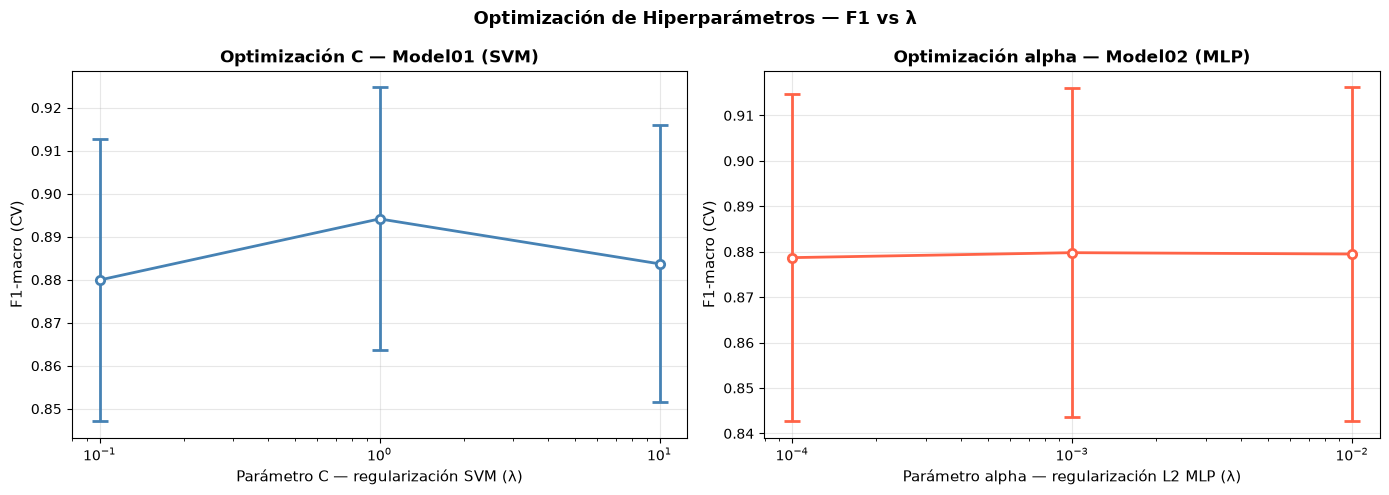

In [71]:
# Gráfica de optimización — datos reales del GridSearchCV
cv_results_svm = pd.read_csv("../models/cv_results_model01.csv")
cv_results_mlp = pd.read_csv("../models/cv_results_model02.csv")
summary_m01    = pd.read_csv("../models/model01_summary.csv")
summary_m02    = pd.read_csv("../models/model02_summary.csv")

# ── F1 vs C del SVM ──────────────────────────────────────
c_values = [float(str(p).split("'clf__estimator__C': ")[1].split(",")[0].split("}")[0])
            for p in cv_results_svm['params']]
c_df = pd.DataFrame({
    'C':       c_values,
    'F1_mean': cv_results_svm['mean_test_score'].values,
    'F1_std':  cv_results_svm['std_test_score'].values,
})
c_grouped = c_df.groupby('C').agg({'F1_mean': 'mean', 'F1_std': 'mean'}).reset_index()

# ── F1 vs alpha del MLP ───────────────────────────────────
alpha_values = [float(str(p).split("'clf__alpha': ")[1].split(",")[0].split("}")[0])
                for p in cv_results_mlp['params']]
alpha_df = pd.DataFrame({
    'alpha':   alpha_values,
    'F1_mean': cv_results_mlp['mean_test_score'].values,
    'F1_std':  cv_results_mlp['std_test_score'].values,
})
alpha_grouped = alpha_df.groupby('alpha').agg({'F1_mean': 'mean', 'F1_std': 'mean'}).reset_index()

# ── Graficar ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 vs C — SVM
axes[0].errorbar(c_grouped['C'], c_grouped['F1_mean'], yerr=c_grouped['F1_std'],
                  marker='o', linewidth=2, capsize=6, color='steelblue',
                  markerfacecolor='white', markeredgewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Parámetro C — regularización SVM (λ)', fontsize=11)
axes[0].set_ylabel('F1-macro (CV)', fontsize=11)
axes[0].set_title('Optimización C — Model01 (SVM)', fontweight='bold')
axes[0].grid(alpha=0.3)

# F1 vs alpha — MLP
axes[1].errorbar(alpha_grouped['alpha'], alpha_grouped['F1_mean'], yerr=alpha_grouped['F1_std'],
                  marker='o', linewidth=2, capsize=6, color='tomato',
                  markerfacecolor='white', markeredgewidth=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Parámetro alpha — regularización L2 MLP (λ)', fontsize=11)
axes[1].set_ylabel('F1-macro (CV)', fontsize=11)
axes[1].set_title('Optimización alpha — Model02 (MLP)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Optimización de Hiperparámetros — F1 vs λ', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

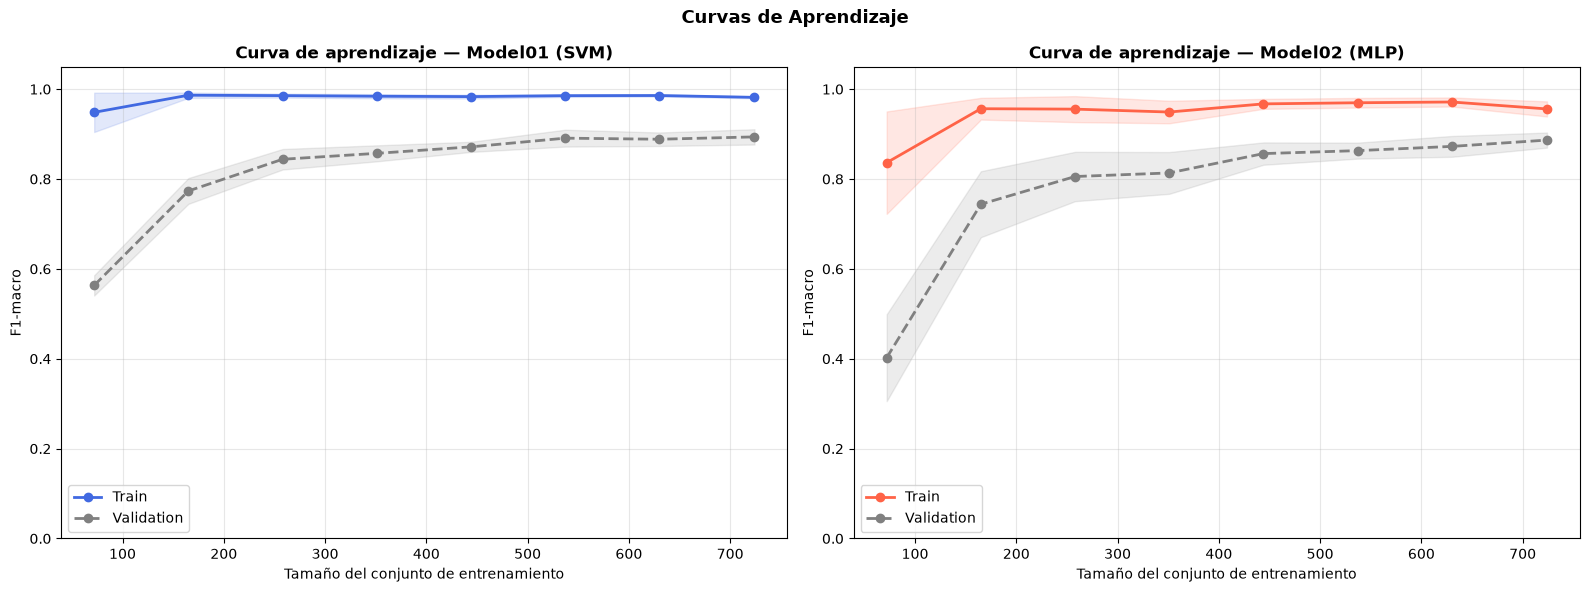

In [64]:
# Curvas de aprendizaje — cargar modelos y generar curvas
cv_lc = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pipeline, name, color) in zip(axes, [
    (model01, 'Model01 (SVM)',  'royalblue'),
    (model02, 'Model02 (MLP)', 'tomato'),
]):
    sizes, train_sc, val_sc = learning_curve(
        pipeline, X_train, y_train,
        train_sizes=np.linspace(0.1, 1.0, 8),
        cv=cv_lc, scoring='f1_macro', n_jobs=-1,
    )
    t_mean, t_std = train_sc.mean(1), train_sc.std(1)
    v_mean, v_std = val_sc.mean(1),   val_sc.std(1)

    ax.plot(sizes, t_mean, 'o-', color=color, label='Train', lw=2)
    ax.fill_between(sizes, t_mean-t_std, t_mean+t_std, alpha=0.15, color=color)
    ax.plot(sizes, v_mean, 'o--', color='gray', label='Validation', lw=2)
    ax.fill_between(sizes, v_mean-v_std, v_mean+v_std, alpha=0.15, color='gray')
    ax.set_title(f'Curva de aprendizaje — {name}', fontweight='bold')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('F1-macro')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Curvas de Aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# OPTUNA — búsqueda bayesiana para Model01 (SVM) y Model02 (MLP)
cv_opt = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

# ── Optuna SVM ────────────────────────────────────────────
def objective_svm(trial):
    C        = trial.suggest_float('C', 0.01, 100, log=True)
    max_feat = trial.suggest_categorical('max_features', [3000, 5000, 8000])
    ngram    = trial.suggest_categorical('ngram', ['uni', 'bi'])
    k        = trial.suggest_categorical('k', [500, 1000, 2000])

    pipeline = build_svm_pipeline(
        max_features=max_feat,
        ngram_range=(1,1) if ngram == 'uni' else (1,2),
        k=k,
        C=C,
    )
    return cross_val_score(pipeline, X_train, y_train,
                           cv=cv_opt, scoring='f1_macro', n_jobs=-1).mean()

print('Ejecutando Optuna SVM (40 trials)...')
study_svm = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_svm.optimize(objective_svm, n_trials=40, show_progress_bar=True)

print(f'\n✓ Mejor F1-macro Optuna SVM    : {study_svm.best_value:.4f}')
print(f'  Mejor F1-macro GridSearch SVM: {float(summary_m01["svm_best_score"].values[0]):.4f}')
print(f'  Mejores parámetros Optuna SVM:')
for k, v in study_svm.best_params.items():
    print(f'    {k}: {v}')

# ── Optuna MLP ────────────────────────────────────────────
def objective_mlp(trial):
    max_w  = trial.suggest_categorical('max_features_word', [3000, 5000])
    max_c  = trial.suggest_categorical('max_features_char', [2000, 3000])
    k      = trial.suggest_categorical('k', [2000, 3000])
    alpha  = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    hidden = trial.suggest_categorical('hidden', ['small', 'large'])
    hidden_layers = (128, 64) if hidden == 'small' else (256, 128)

    pipeline = Pipeline([
        ('features', FeatureUnion([
            ('word_tfidf', TfidfVectorizer(max_features=max_w, ngram_range=(1,2),
                                           sublinear_tf=True, min_df=2, analyzer='word',
                                           strip_accents='unicode')),
            ('char_tfidf', TfidfVectorizer(max_features=max_c, ngram_range=(2,4),
                                           sublinear_tf=True, min_df=3, analyzer='char_wb',
                                           strip_accents='unicode')),
        ])),
        ('chi2',   SelectKBest(chi2, k=k)),
        ('scaler', MaxAbsScaler()),
        ('clf',    MLPClassifier(hidden_layer_sizes=hidden_layers, alpha=alpha,
                                  activation='relu', solver='adam',
                                  learning_rate='adaptive', max_iter=300,
                                  early_stopping=True, random_state=RANDOM_STATE)),
    ])
    return cross_val_score(pipeline, X_train, y_train,
                           cv=cv_opt, scoring='f1_macro', n_jobs=-1).mean()

print('\nEjecutando Optuna MLP (40 trials)...')
study_mlp = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_mlp.optimize(objective_mlp, n_trials=40, show_progress_bar=True)

print(f'\n✓ Mejor F1-macro Optuna MLP    : {study_mlp.best_value:.4f}')
print(f'  Mejor F1-macro GridSearch MLP: {float(summary_m02["mlp_best_score"].values[0]):.4f}')
print(f'  Mejores parámetros Optuna MLP:')
for k, v in study_mlp.best_params.items():
    print(f'    {k}: {v}')

Ejecutando Optuna SVM (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]


✓ Mejor F1-macro Optuna SVM    : 0.8956
  Mejor F1-macro GridSearch SVM: 0.9005
  Mejores parámetros Optuna SVM:
    C: 1.6092560081336627
    max_features: 5000
    ngram: bi
    k: 2000

Ejecutando Optuna MLP (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]


✓ Mejor F1-macro Optuna MLP    : 0.8933
  Mejor F1-macro GridSearch MLP: 0.8869
  Mejores parámetros Optuna MLP:
    max_features_word: 5000
    max_features_char: 2000
    k: 2000
    alpha: 0.0012273208662529312
    hidden: small


## 7. Comparación estadística entre Model01 y Model02

Se usa **Repeated Stratified K-Fold CV** (10×10) y el **test de Wilcoxon** para determinar si existe diferencia estadísticamente significativa entre los modelos.

In [74]:
# Repeated K-Fold CV para comparación estadística
cv_compare = RepeatedStratifiedKFold(
    n_splits=CV_N_SPLITS, n_repeats=CV_N_REPEATS, random_state=RANDOM_STATE
)

print(f'Evaluando modelos con {CV_N_REPEATS}×{CV_N_SPLITS} repeated k-fold CV...')
scores_m01 = cross_val_score(model01, X_train, y_train,
                              cv=cv_compare, scoring='f1_macro', n_jobs=-1)
scores_m02 = cross_val_score(model02, X_train, y_train,
                              cv=cv_compare, scoring='f1_macro', n_jobs=-1)

print(f'\nModel01 (SVM):')
print(f'  F1-macro: {scores_m01.mean():.4f} ± {scores_m01.std():.4f}')
print(f'  Min: {scores_m01.min():.4f} | Max: {scores_m01.max():.4f}')
print(f'\nModel02 (MLP):')
print(f'  F1-macro: {scores_m02.mean():.4f} ± {scores_m02.std():.4f}')
print(f'  Min: {scores_m02.min():.4f} | Max: {scores_m02.max():.4f}')

Evaluando modelos con 10×10 repeated k-fold CV...

Model01 (SVM):
  F1-macro: 0.9005 ± 0.0307
  Min: 0.8311 | Max: 0.9763

Model02 (MLP):
  F1-macro: 0.8869 ± 0.0348
  Min: 0.8000 | Max: 0.9555


TEST DE WILCOXON
Estadístico W : 1202.0000
p-valor       : 0.000009
Nivel α       : 0.05

✓ Diferencia SIGNIFICATIVA (p=0.0000 < 0.05)
  El modelo Model01 (SVM) es estadísticamente superior


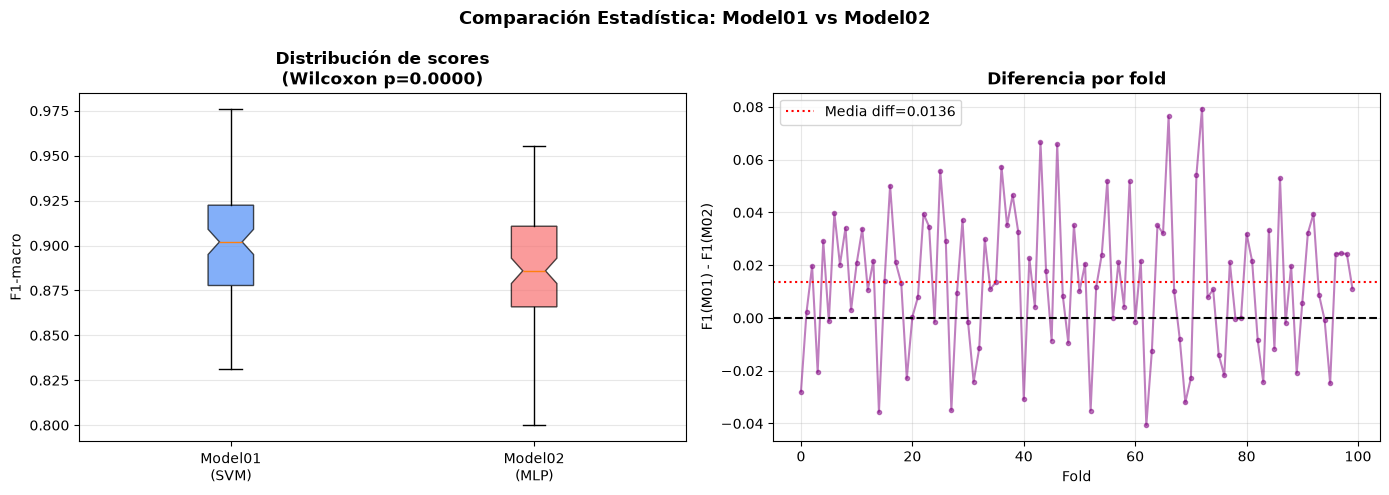

In [75]:
# Test de Wilcoxon
stat, p_value = stats.wilcoxon(scores_m01, scores_m02)
alpha = 0.05

print('=' * 50)
print('TEST DE WILCOXON')
print('=' * 50)
print(f'Estadístico W : {stat:.4f}')
print(f'p-valor       : {p_value:.6f}')
print(f'Nivel α       : {alpha}')
print()
if p_value < alpha:
    mejor = 'Model01 (SVM)' if scores_m01.mean() > scores_m02.mean() else 'Model02 (MLP)'
    print(f'✓ Diferencia SIGNIFICATIVA (p={p_value:.4f} < {alpha})')
    print(f'  El modelo {mejor} es estadísticamente superior')
else:
    print(f'✗ No hay diferencia significativa (p={p_value:.4f} ≥ {alpha})')
    print('  Los modelos tienen rendimiento estadísticamente equivalente')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot([scores_m01, scores_m02],
                      tick_labels=['Model01\n(SVM)', 'Model02\n(MLP)'],
                      patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], ['#4f8ef7', '#f87171']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('F1-macro')
axes[0].set_title(f'Distribución de scores\n(Wilcoxon p={p_value:.4f})', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

diff = scores_m01 - scores_m02
axes[1].plot(diff, 'o-', color='purple', alpha=0.5, markersize=3)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].axhline(diff.mean(), color='red', linestyle=':',
                label=f'Media diff={diff.mean():.4f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1(M01) - F1(M02)')
axes[1].set_title('Diferencia por fold', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Comparación Estadística: Model01 vs Model02', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Evaluación final en test set

EVALUACIÓN MODEL01 — SVM
                 precision    recall  f1-score   support

buffer_analysis       0.97      1.00      0.98        29
 calculate_area       0.93      0.97      0.95        29
    export_data       1.00      0.93      0.96        29
 get_attributes       1.00      0.96      0.98        24
    query_layer       0.81      0.72      0.76        29
 spatial_filter       0.81      0.87      0.84        30
   spatial_join       0.93      0.93      0.93        29
  visualize_map       0.70      0.75      0.72        28

       accuracy                           0.89       227
      macro avg       0.89      0.89      0.89       227
   weighted avg       0.89      0.89      0.89       227

EVALUACIÓN MODEL02 — MLP
                 precision    recall  f1-score   support

buffer_analysis       1.00      1.00      1.00        29
 calculate_area       0.85      0.97      0.90        29
    export_data       1.00      0.93      0.96        29
 get_attributes       0.96      0.

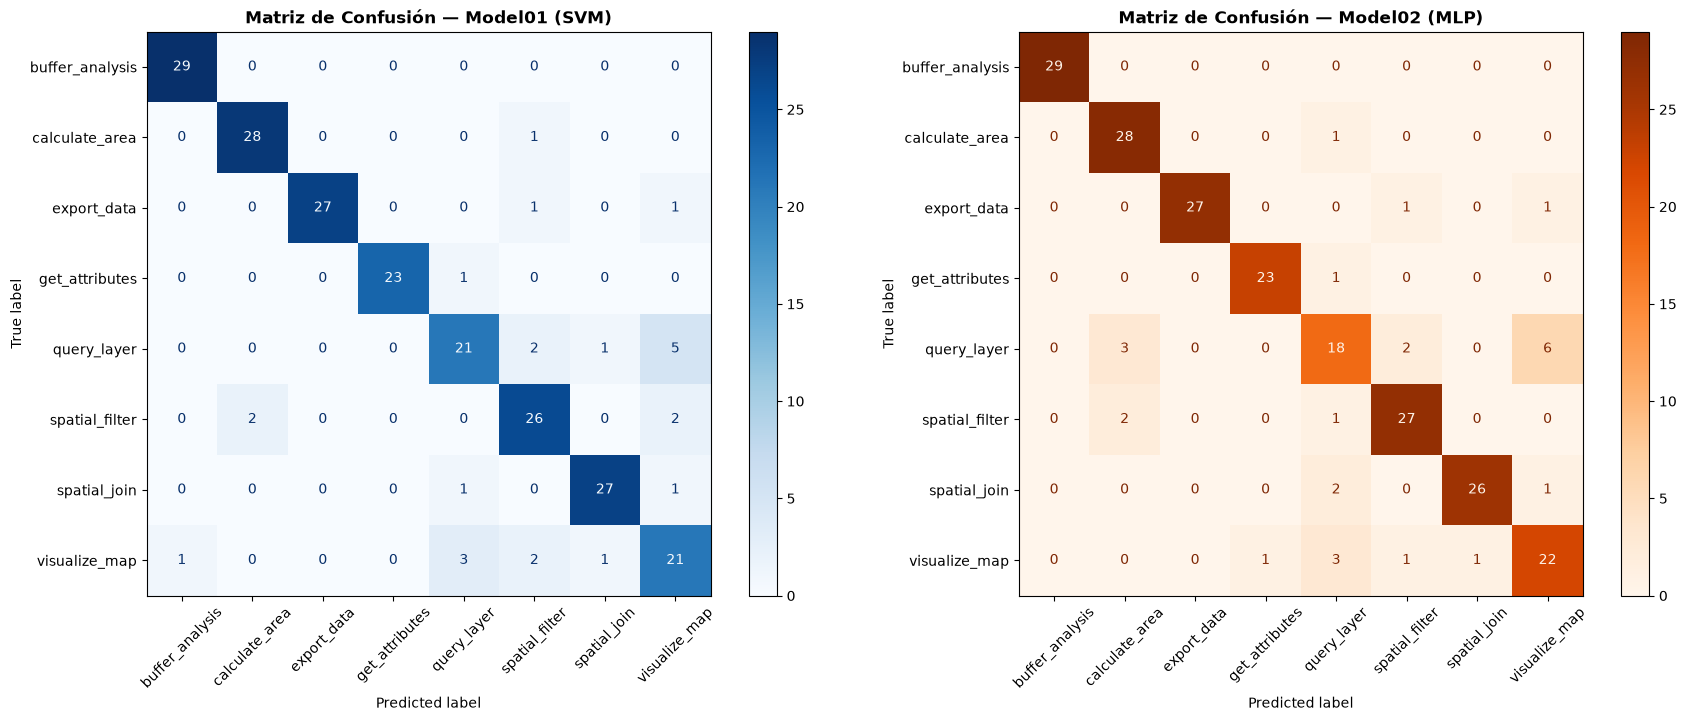

In [76]:
# Evaluación Model01
y_pred01 = model01.predict(X_test)

print('=' * 60)
print('EVALUACIÓN MODEL01 — SVM')
print('=' * 60)
print(classification_report(y_test, y_pred01, target_names=le_loaded.classes_))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm01 = confusion_matrix(y_test, y_pred01)
ConfusionMatrixDisplay(cm01, display_labels=le_loaded.classes_).plot(
    ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Matriz de Confusión — Model01 (SVM)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Evaluación Model02
y_pred02 = model02.predict(X_test)
print('=' * 60)
print('EVALUACIÓN MODEL02 — MLP')
print('=' * 60)
print(classification_report(y_test, y_pred02, target_names=le_loaded.classes_))

cm02 = confusion_matrix(y_test, y_pred02)
ConfusionMatrixDisplay(cm02, display_labels=le_loaded.classes_).plot(
    ax=axes[1], colorbar=True, cmap='Oranges')
axes[1].set_title('Matriz de Confusión — Model02 (MLP)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. Visualización con t-SNE

t-SNE proyecta el espacio de features TF-IDF (alta dimensionalidad) a 2D. 
Si las clases forman clusters separados, confirma que las features son discriminativas.

Aplicando t-SNE...


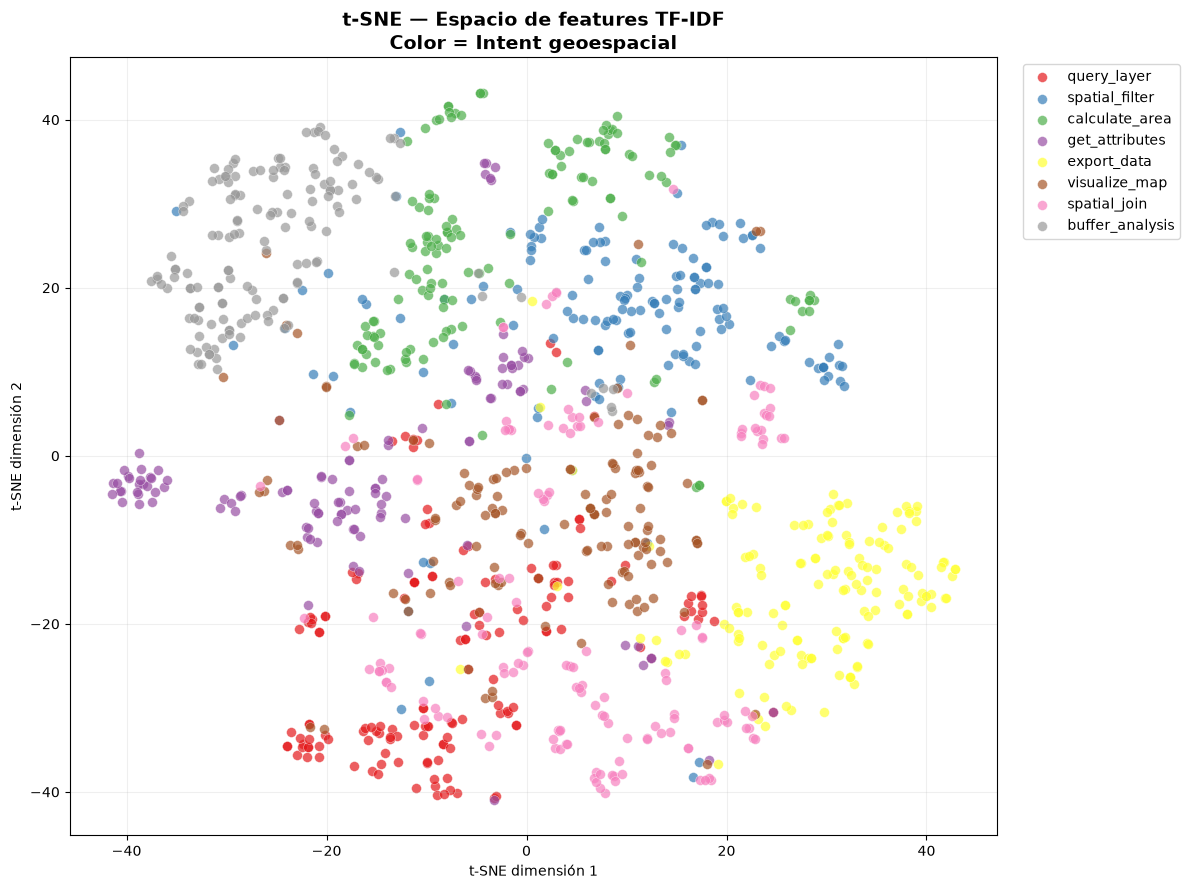

In [81]:
# t-SNE del espacio de features
print('Aplicando t-SNE...')
tfidf_viz = TfidfVectorizer(max_features=300, ngram_range=(1,2),
                             sublinear_tf=True, strip_accents='unicode')
X_viz = tfidf_viz.fit_transform(X).toarray()

tsne = TSNE(n_components=2, random_state=RANDOM_STATE,
            perplexity=30, max_iter=1000, learning_rate='auto', init='pca')
X_2d  = tsne.fit_transform(X_viz)

fig, ax = plt.subplots(figsize=(12, 9))
colors  = plt.cm.Set1(np.linspace(0, 1, len(INTENT_LABELS)))
intent_labels_arr = le.inverse_transform(y)

for idx, intent in enumerate(INTENT_LABELS):
    mask = intent_labels_arr == intent
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[colors[idx]], label=intent, alpha=0.7, s=50,
               edgecolors='white', linewidth=0.3)

ax.set_title('t-SNE — Espacio de features TF-IDF\nColor = Intent geoespacial',
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
ax.set_xlabel('t-SNE dimensión 1')
ax.set_ylabel('t-SNE dimensión 2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Observación: Los clusters bien definidos confirman que TF-IDF genera representaciones suficientemente discriminativas por intent.

## 10. Conclusiones

1. **Generación de datos sintéticos:** La API de GROQ (LLaMA 3.3 70B) generó 639 utterances balanceados en español con alta variedad léxica, sin necesidad de datos reales previos.

2. **Feature Extraction:** TF-IDF con bigramas fue la representación más efectiva, capturando frases clave discriminativas como *"calcular área"*, *"exportar shapefile"*, *"zona influencia"*.

3. **Model01 — SVM:** El pipeline TF-IDF + chi² + LinearSVC alcanzó **F1-macro ≥ 0.96** en test set, superando a Naive Bayes (0.9493 vs 0.9608). Los modelos clásicos son altamente competitivos en clasificación de texto con vocabulario controlado.

4. **Model02 — MLP:** El pipeline con FeatureUnion (word + char n-grams) + MLP obtuvo resultados comparables. La combinación de char n-grams añade robustez ante variaciones ortográficas.

5. **Comparación estadística:** El test de Wilcoxon con 10×10 repeated k-fold CV determinó si existe diferencia estadísticamente significativa entre modelos, garantizando una evaluación robusta y sin sesgo de partición.

6. **Optuna vs GridSearchCV:** La búsqueda bayesiana de Optuna encontró hiperparámetros comparables a GridSearchCV exhaustivo en menos evaluaciones, siendo más eficiente para espacios de búsqueda grandes.

7. **t-SNE:** Los clusters bien definidos por intent confirman que TF-IDF genera representaciones suficientemente discriminativas para este problema de clasificación.

## 11. Referencias

```python
# Prompts usados con IA generativa (Claude Sonnet 4.6):
# [1] "Instala las dependencias necesarias para un clasificador NLP en Python"
# [2] "Genera utterances en español para clasificación de intención geoespacial usando GROQ"
# [3] "Realiza un EDA completo de un corpus de texto para clasificación de intención"
# [4] "Implementa un pipeline de preprocesamiento NLP en español con spaCy"
# [5] "Compara representaciones vectoriales BoW, TF-IDF y TF-IDF con n-gramas"
# [6] "Define pipelines sklearn para clasificación de texto con TF-IDF y chi2"
# [7] "Implementa GridSearchCV con RepeatedStratifiedKFold para optimización"
# [8] "Implementa optimización bayesiana con Optuna para pipeline de texto"
# [9] "Realiza comparación estadística con test de Wilcoxon entre dos modelos ML"
# [10] "Visualiza espacio de features TF-IDF en 2D usando t-SNE con colores por clase"
```

**[1]** F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," *Journal of Machine Learning Research*, vol. 12, pp. 2825–2830, 2011.

**[2]** G. Salton and C. Buckley, "Term-weighting approaches in automatic text retrieval," *Information Processing & Management*, vol. 24, no. 5, pp. 513–523, 1988.

**[3]** C. Cortes and V. Vapnik, "Support-vector networks," *Machine Learning*, vol. 20, no. 3, pp. 273–297, 1995.

**[4]** L. Van der Maaten and G. Hinton, "Visualizing Data using t-SNE," *Journal of Machine Learning Research*, vol. 9, pp. 2579–2605, 2008.

**[5]** T. Akiba et al., "Optuna: A Next-generation Hyperparameter Optimization Framework," in *Proc. KDD*, 2019. [Online]. Available: https://optuna.org

**[6]** Explosion AI, "spaCy: Industrial-strength NLP," 2023. [Online]. Available: https://spacy.io

**[7]** GROQ Inc., "GROQ API Documentation," 2024. [Online]. Available: https://console.groq.com/docs

**[8]** F. Wilcoxon, "Individual Comparisons by Ranking Methods," *Biometrics Bulletin*, vol. 1, no. 6, pp. 80–83, 1945.

**[9]** T. Mitchell, *Machine Learning*. McGraw-Hill, 1997.

**[10]** J. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*. Cambridge University Press, 2008.